# Stark shift of an interlayer exciton

This notebook walks through a full analysis of a dual-gated MoSe₂/WSe₂
heterobilayer, from raw AttoCube export to an extracted exciton dipole length.

## The system

The sample is a MoSe₂/WSe₂ heterobilayer encapsulated in hBN, with a top and a
bottom gate. The band alignment is type II, so the lowest-energy exciton is
*interlayer*: the electron sits in the MoSe₂ layer and the hole in the WSe₂,
separated by roughly one interlayer spacing. That spatial separation gives the
exciton a permanent out-of-plane dipole moment **p** = *e·d*, where *d* is the
electron–hole separation — the quantity we extract below.

Driving the two gates against each other applies an out-of-plane electric field
*F* across the stack while leaving the carrier density roughly unchanged, so the
field can be swept without simultaneously doping the channel.

## The physics

A permanent dipole couples linearly to the applied field, so the emission energy
shifts as

$$E(F) = E_0 - e\,d\,F$$

and the slope of peak energy against field returns the dipole length directly.
This linear shift is itself the signature of interlayer character: an intralayer
exciton has no permanent out-of-plane dipole and shifts only quadratically,
through its polarizability. For a heterobilayer we expect *d* on the order of the
interlayer spacing (a few Ångström), which makes the fitted value a useful
sanity check on the measurement rather than just a number.

Two caveats that the data cannot resolve on its own:

- The fit returns the **magnitude** of the dipole length. Which sign the shift
  takes depends on the stacking order and on which acquisition channel drove
  which gate — neither of which is recorded in the file, so the gate mapping is
  declared explicitly when the scan is loaded.
- The field is computed from the *declared* hBN thicknesses and dielectric
  constants, so its accuracy is set by how well the stack was characterised.

## Why the hBN thicknesses matter

The two gate voltages are not independent knobs for field and density — each one
moves both. Which combination holds the density fixed is set entirely by the two
hBN thicknesses, which is why they are the first thing declared in the notebook.

The field depends on the **difference** of the two gate voltages, over the total
thickness of the stack:

$$F = \frac{V_\mathrm{BG} - V_\mathrm{TG}}{d_\mathrm{tot}}\cdot
      \frac{\varepsilon_\mathrm{stack}}{\varepsilon_\mathrm{2D}},
\qquad d_\mathrm{tot} = d_\mathrm{2D} + d_\mathrm{hBN}^\mathrm{top}
                                      + d_\mathrm{hBN}^\mathrm{bot}$$

The carrier density depends on a **capacitance-weighted sum**, where each gate
is weighted by its own hBN alone — the TMDC is the counter-electrode of each
capacitor, not a slab inside it:

$$n = \frac{1}{e}\left[C_\mathrm{t}V_\mathrm{TG} + C_\mathrm{b}V_\mathrm{BG}\right],
\qquad C_i = \frac{\varepsilon_0\varepsilon_\mathrm{hBN}}{d_\mathrm{hBN}^{\,i}}$$

Setting $\delta n = 0$ gives the direction in gate space that changes the field
at fixed density:

$$\frac{\delta V_\mathrm{TG}}{\delta V_\mathrm{BG}}
   = -\frac{C_\mathrm{b}}{C_\mathrm{t}}
   = -\frac{d_\mathrm{hBN}^\mathrm{top}}{d_\mathrm{hBN}^\mathrm{bot}}$$

So the familiar equal-and-opposite sweep, $V_\mathrm{TG} = -V_\mathrm{BG}$, is
only a constant-density sweep for a **symmetric** stack. This sample has 53 nm
of hBN on top and 46 nm below, so the thicker top gate is the weaker one and has
to swing about 15 % harder to keep the density fixed. Sweeping the gates
symmetrically instead leaves a residual doping of

$$\frac{\delta n}{\delta V} = \frac{C_\mathrm{b} - C_\mathrm{t}}{e}
  \approx 6 \times 10^{10}\ \mathrm{cm^{-2}\ V^{-1}}$$

which over a $\pm 5$ V sweep is a few $10^{11}\ \mathrm{cm^{-2}}$ — enough to
move spectral weight between the neutral exciton and its charged counterpart,
which would then be read as part of the Stark shift.

The capacitance ratio is purely geometric, so it holds even though the absolute
density from these capacitances is an upper bound (quantum and interface-trap
capacitance sit in series and reduce the effective value).

### Reading the sweep back off the data

The loader reports how the gates were actually driven, independently of what we
intended:

```python
print(scan.gate_mode)
```

```
dual-gate, anti-correlated (field-like)
```

This is read from the correlation between the two gate channels, so it confirms
the sweep was anti-symmetric — field-like rather than doping-like. It is a sign
test, not a ratio test: it cannot tell you whether the *magnitudes* satisfied
the condition above. That part is on the stack geometry, which is why we declare
it explicitly rather than let the loader guess.

## What this notebook covers

The analysis runs in four steps, each demonstrating a different part of the
library:

1. **Loading** — declare the stack with `DeviceGeometry`, then read the
   dual-gate sweep with `ACSpectralSweep`. The geometry is what turns gate
   voltages into a field, and the gate mapping is stated explicitly at load
   time, so the scan carries its own physical context rather than leaving it in
   the analyst's head.
2. **Plotting** — `plotting.plot_spectral_map` shows the emission spectra
   against applied field in one call. Every plotting function returns its
   figure, axes and artists, so the same call composes into a multi-panel
   figure without a second API; we do exactly that later on.
3. **Extracting the dipole** — `fitting.extract_dipole_length` fits a lineshape
   at each field point and a straight line through the resulting peak energies,
   returning a `DipoleResult` that carries the dipole length, its uncertainty,
   the per-point fits and the R². `plotting.plot_stark_shift` plots the shift
   the fit was taken from, so the number can be checked against the data it
   came from.

## References

- Ciarrocchi, A. et al. Polarization switching and electrical control of
  interlayer excitons in two-dimensional van der Waals heterostructures.
  *Nature Photon.* **13**, 131–136 (2019).
- Jauregui, L. A. et al. Electrical control of interlayer exciton dynamics in
  atomically thin heterostructures. *Science* **366**, 870–875 (2019).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import leman as tmdc
import os
from cmcrameri import cm  
from pathlib import Path
import matplotlib.animation as animation

We load our sample geometry. We define our measured our top and bottom hBN thicknesses. Defining the sample will be important for the calculation of the electric field inside the heterostructure.

In [2]:
sample_geometry = tmdc.DeviceGeometry(
    tmdc_stack = [
        tmdc.StackLayer("MoSe2"),
        tmdc.StackLayer("WSe2"),
    ],
    d_hbn_top = 53, # in nm
    d_hbn_bottom = 46, # in nm
)

Load the file of interest and call our data loader. For this measurement, we used a voltage scan of the top and bottom contacts to generate an electric field within the heterostructure. We pass our sample geometry into this data loader to automatically calculate the electric field applied.

In [3]:
filename = "PL-dual-gate-sweep_26_05_15_14_03_18_iter_0.csv"

scan = tmdc.ACSpectralSweep(
    os.path.join("./data/stark-shift", filename),  # Define the file to be used. Accepts .csv or .h5 files.
    spectra_type = "PL",                           # Required for CSV input. Type of measurement. Can be "PL" or "R" (reflectance) or "RC" (reflectance contrast)
    sweep = "electric_field",                      # Defines the sweeping variable
    # sweep_label = "Electric field (MV/m)",       # Optional. Label for the sweeping variable. If none is passed, defaults to the inferred label provided by 'sweep'
    geometry=sample_geometry,                      # Define the geometry of the sample. Necessary for the calculation of the electric field experienced by the heterostructure
    bg_region_eV = (1.42,1.44),                    # Applies background subtraction in eV with provided range as the window. Must be used if apply_jacobian = True
    # bg_region_nm = (,)                           # Applies background subtraction but in nm space
    apply_jacobian = True,                         # For transformation of PL intensity in nm [I(lambda)] to PL intensity in eV [I(eV)]. Defaults to False.
    # bg_spectrum = None,                          # Optional. Path or SingleSpectrum object or array. Applies a point-wise spectrum subtraction to the scan.
    # reference = None,                            # Optional. Path, SingleSpecturm or array. Reference spectrum used for reflectance contrast calculation
    # contrast = None,                             # Optional. str. Which contrast to use for reflectivity: differential contrast ("contrast") or ratio ("ratio").
    gates = {"top": "V_A", "bottom": "V_B"},       # Maps the recorded voltage names to the physical electrodes of the device.
    # roi                                          # Selects which spectrometer ROI to use. Defaults to 1. 1 or 2 possible.
    cosmic_rays = {}
    )
print(scan)

ACSpectralSweep — 61 sweeps × 1340 pixels  [Photoluminescence]
  File        : ./data/stark-shift\PL-dual-gate-sweep_26_05_15_14_03_18_iter_0.csv
  λ range     : 868.6 – 989.9 nm
  Energy range: 1.252 – 1.427 eV
  Sweep       : electric_field — -173 → 173 mV/nm
  Gates       : dual-gate, anti-correlated (field-like)  (top ← 'V_A', bottom ← 'V_B')
  Power       : 56.0 → 56.6 µW
  Varying     : I_B, I_A, V_A, V_B
  ROI         : ExpROI1
  Cosmic rays : 29 pixels replaced
  BG region   : 861.0 – 873.1 nm
  Jacobian    : applied



If we are unsure about the 

In [4]:
scan.gate_mode

'dual-gate, anti-correlated (field-like)'

We have a number of properties of the variable `scan` which we can access and manipulate manually if we wish. Now we can call our plotting function to show our PL spectra as a function of applied electric field.

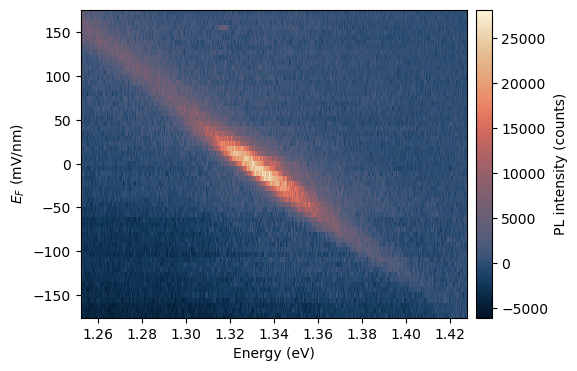

In [5]:
fig, ax, mesh = tmdc.plotting.plot_spectral_map(
    scan = scan,         # The scan object
    # ax =,              # Optional. The axis to plot on. If none is passed, a new figure and axis are created.
    x_axis = "energy",   # Optional. The x-axis to plot. Can be "energy" or "wavelength". Defaults to "energy".
    rescale_img = False, # Optional. If True, rescales intensity to [0, 1] before plotting. Defaults to False.
    cmap = "cmc.lipari",
)

In [ ]:
dipole_fit = tmdc.fitting.extract_dipole_length(
    scan     = scan,
    x_range  = (1.30, 1.38),
    model    = "lorentzian",
    ef_range = (-75, 75),           # in mV/nm
)

print(dipole_fit)

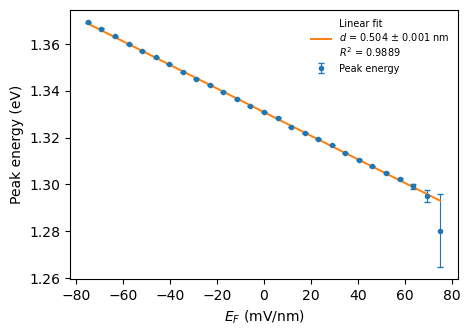

In [7]:
fig, ax = tmdc.plotting.plot_stark_shift(
    dipole_result = dipole_fit,
)

## Generating custom figures

So far running our plot commands generates one figure. We can instead create an existing set of axes in matplotlib and use those instead of creating new ones each time we run the function. Doing this allows us to manipulate our figures in a more precise way. For our dipole length plot, we could also do

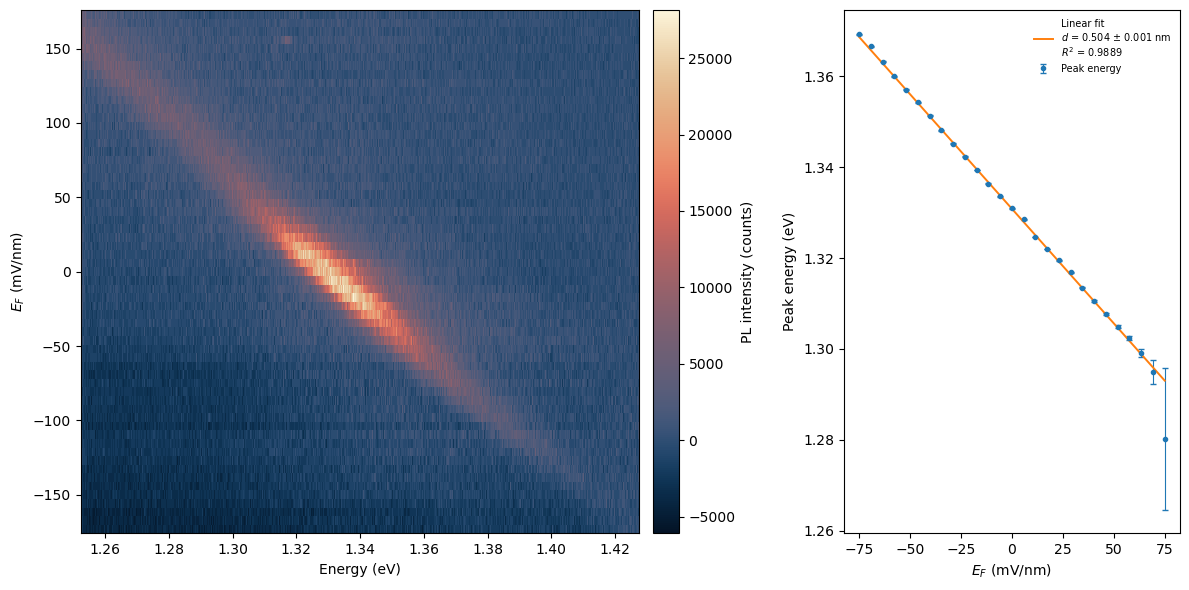

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [2, 1]})

tmdc.plotting.plot_spectral_map(
    scan = scan,
    ax   = axes[0],
    cmap = "cmc.lipari"
)

tmdc.plotting.plot_stark_shift(
    dipole_result = dipole_fit,
    ax            = axes[1],
)

fig.tight_layout()